# exercise: makemore part 2 - mlp

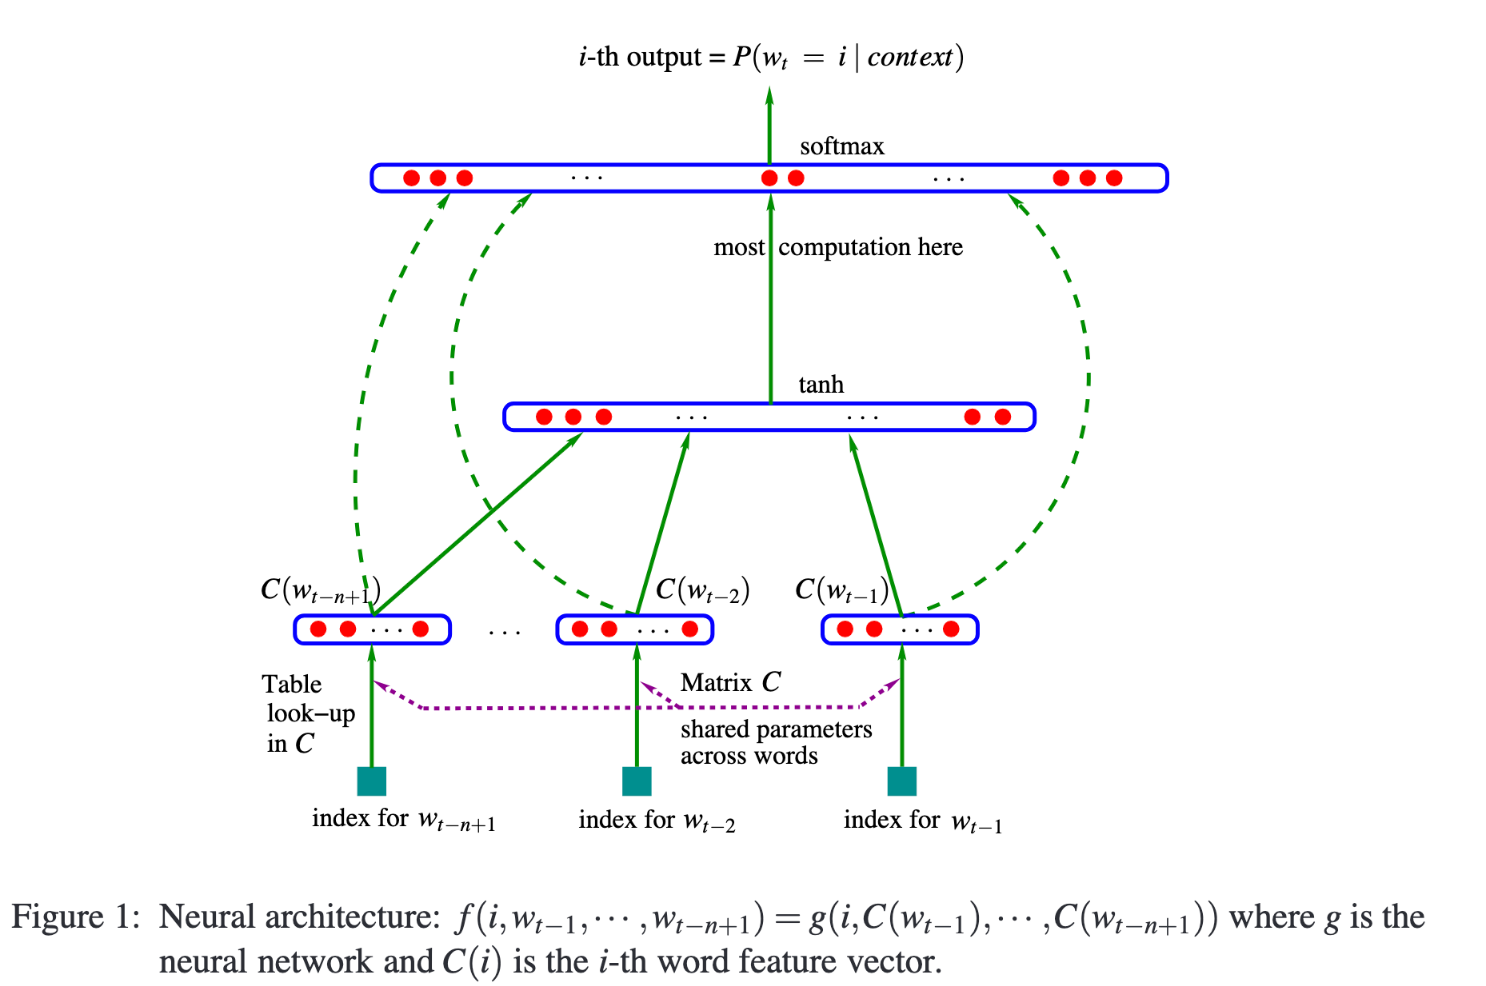

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures

%matplotlib inline

In [2]:
words = open("../data/names.txt", "r").read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
words[:1]

['emma']

In [5]:
chars = sorted(set("".join(words)))  # <- list of chars from "a" to "z"
stoi = {s: i + 1 for i, s in enumerate(chars)}  # <- dict, {".": 0, "a": 1, "b": 2 ...}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}  # <- dict, {0: ".", 1: "a", 2: "b" ...}

In [6]:
block_size = 3  # context length: how many characters do we take to predict the next one?

In [7]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [8]:
X, Y = build_dataset(words[:1])

In [9]:
for xs, ys in zip(X, Y):
    print("".join(itos[i.item()] for i in xs), "->", itos[ys.item()])

... -> e
..e -> m
.em -> m
emm -> a
mma -> .


In [10]:
# build the dataset
block_size = 3

import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [11]:
print(Xtr.shape, Ytr.shape)
print(Xdev.shape, Ydev.shape)
print(Xte.shape, Yte.shape)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [13]:
sum(p.nelement() for p in parameters)  # number of parameters in total

11897

In [ ]:
for p in parameters:
    p.requires_grad = True

In [20]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

lri = []
lossi = []
stepi = []

In [22]:
from tqdm import tqdm

for i in tqdm(range(200000)):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 200)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

100%|██████████| 200000/200000 [05:44<00:00, 581.20it/s] 


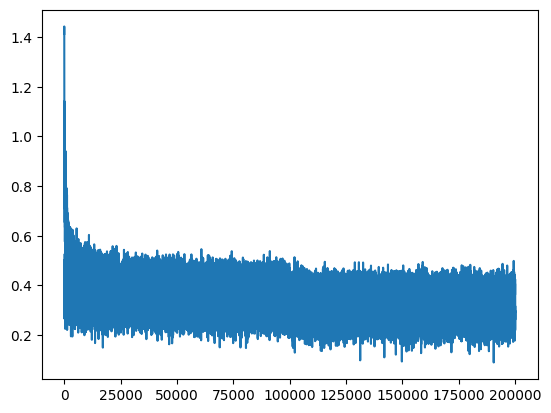

In [23]:
plt.plot(stepi, lossi)

In [30]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1172, grad_fn=<NllLossBackward0>)

In [31]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1612, grad_fn=<NllLossBackward0>)

In [33]:
# inference
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size  # initialize with all ...
    while True:
        emb = C[torch.tensor([context])]  # (1, block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))

cerie.
coullerailah.
tyhan.
maimittainella.
kaman.
arremiyah.
javariila.
shidziellahogpantedrael.
emia.
sadel.
tiaviyah.
folstihaniel.
viah.
asu.
jaded.
antil.
pyan.
isana.
rafey.
jayzer.


## Exercises:
E01: Tune the hyperparameters of the training to beat my best validation loss of 2.2

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt  # for making figures
import random
from tqdm import tqdm

%matplotlib inline

In [3]:
words = open("../data/names.txt", "r").read().splitlines()

chars = sorted(set("".join(words)))  # <- list of chars from "a" to "z"
stoi = {s: i + 1 for i, s in enumerate(chars)}  # <- dict, {".": 0, "a": 1, "b": 2 ...}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}  # <- dict, {0: ".", 1: "a", 2: "b" ...}

In [4]:
num_chars = 27
num_iterations = 100000
batch_size = 128
block_size = 4

In [5]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 4]) torch.Size([182625])
torch.Size([22655, 4]) torch.Size([22655])
torch.Size([22866, 4]) torch.Size([22866])


In [32]:
def init_network(emb_dim, block_size, hidden_size):
    input_size = emb_dim * block_size

    g = torch.Generator().manual_seed(2147483647)
    C = torch.randn((num_chars, emb_dim), generator=g, requires_grad=True)
    W1 = torch.randn((input_size, hidden_size), generator=g, requires_grad=True)
    b1 = torch.randn(hidden_size, generator=g, requires_grad=True)
    W2 = torch.randn((hidden_size, num_chars), generator=g, requires_grad=True)
    b2 = torch.randn(num_chars, generator=g, requires_grad=True)
    return [C, W1, b1, W2, b2]

In [33]:
def train(num_iterations, input_size, lr, batch_size, parameters):
    stepi = []
    lossi = []

    C, W1, b1, W2, b2 = parameters

    for i in tqdm(range(num_iterations)):
        # minibatch construct
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))

        # forward pass
        emb = C[Xtr[ix]]
        h = torch.tanh(emb.view(-1, input_size) @ W1 + b1)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Ytr[ix])

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        for p in parameters:
            p.data += -lr * p.grad

        # track stats
        stepi.append(i)
        lossi.append(loss.log10().item())

    # dev loss
    emb = C[Xdev]
    h = torch.tanh(emb.view(-1, input_size) @ W1 + b1)
    logits = h @ W2 + b2
    dev_loss = F.cross_entropy(logits, Ydev)

    print(f"{dev_loss.item()=}")

    plt.plot(stepi, lossi)

    return dev_loss.item()

100%|██████████| 100000/100000 [02:01<00:00, 821.10it/s]


dev_loss.item()=2.225004196166992


100%|██████████| 100000/100000 [01:59<00:00, 838.38it/s]


dev_loss.item()=2.2276923656463623


100%|██████████| 100000/100000 [02:09<00:00, 770.46it/s]


...

dev_loss.item()=2.2027196884155273


100%|██████████| 100000/100000 [02:14<00:00, 745.01it/s]


dev_loss.item()=2.243302583694458


100%|██████████| 100000/100000 [02:48<00:00, 593.67it/s]


dev_loss.item()=2.727635383605957
{'emb_dim': 27, 'hidden_size': 200, 'lr': 0.1, 'dev_loss': 2.179255247116089}


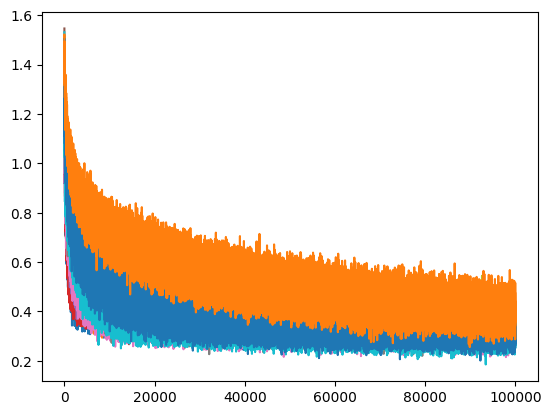

In [196]:
results = []
for emb_dim in [10, 27]:
    for hidden_size in [200, 300]:
        for lr in [0.1, 0.05, 0.01]:
            params = init_network(
                emb_dim=emb_dim,
                block_size=block_size,
                hidden_size=hidden_size,
            )
            dev_loss = train(
                num_iterations=num_iterations,
                input_size=emb_dim * block_size,
                lr=lr,
                batch_size=batch_size,
                parameters=params,
            )
            results.append(
                {
                    "emb_dim": emb_dim,
                    "hidden_size": hidden_size,
                    "lr": lr,
                    "dev_loss": dev_loss,
                }
            )

best = min(results, key=lambda r: r["dev_loss"])
print(best)

In [ ]:
# retrain
best = min(results, key=lambda r: r["dev_loss"])
params = init_network(
    emb_dim=best["emb_dim"],
    block_size=block_size,
    hidden_size=best["hidden_size"],
)

100%|██████████| 100000/100000 [02:06<00:00, 791.36it/s]


dev_loss.item()=2.1576645374298096


2.1576645374298096

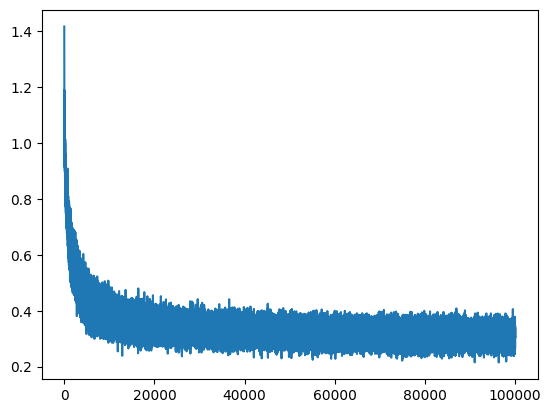

In [198]:
train(num_iterations=num_iterations, input_size=best["emb_dim"] * block_size, lr=best["lr"], batch_size=batch_size, parameters=params)

100%|██████████| 50000/50000 [01:29<00:00, 555.78it/s]

dev_loss.item()=2.1294362545013428


2.1294362545013428

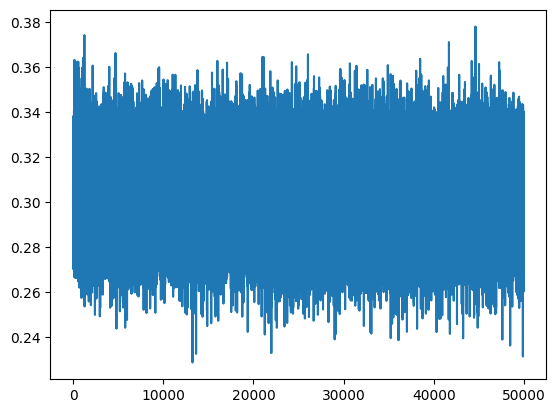

In [199]:
train(num_iterations=50000, input_size=best["emb_dim"] * block_size, lr=0.01, batch_size=256, parameters=params)

100%|██████████| 50000/50000 [01:28<00:00, 562.01it/s]

dev_loss.item()=2.127617359161377


2.127617359161377

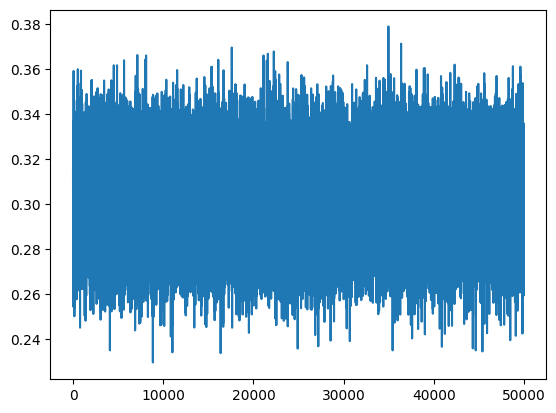

In [200]:
train(num_iterations=50000, input_size=best["emb_dim"] * block_size, lr=0.01, batch_size=256, parameters=params)

In [202]:
# inference
C, W1, b1, W2, b2 = params

g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    out = []
    context = [0] * block_size  # initialize with all ...
    while True:
        emb = C[torch.tensor([context])]  # (1,block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))

cerie.
moulynn.
rochianna.
malimattannaluston.
andr.
samiyah.
javery.
mari.
moriella.
kinzie.


## E02:
I was not careful with the intialization of the network in this video.

1. What is the loss you'd get if the predicted probabilities at initialization were perfectly uniform? What loss do we achieve? 
2. Can you tune the initialization to get a starting loss that is much more similar to (1)?

In [6]:
# loss if probability is uniform
probs_uniform = torch.tensor(1 / 27)
loss = -torch.log(probs_uniform)
print(f"{loss.item()=}")

loss.item()=3.295836925506592


In [7]:
num_chars = 27
num_iterations = 100000
batch_size = 128
block_size = 4
emb_dim = 27
hidden_size = 200
lr = 0.1

In [40]:
# random weight initialization
input_size = emb_dim * block_size

g = torch.Generator().manual_seed(2147483647)

C = torch.randn((num_chars, emb_dim), generator=g, requires_grad=True)
W1 = torch.randn((input_size, hidden_size), generator=g, requires_grad=True)
b1 = torch.randn(hidden_size, generator=g, requires_grad=True)
W2 = torch.randn((hidden_size, num_chars), generator=g, requires_grad=True)
b2 = torch.randn(num_chars, generator=g, requires_grad=True)

# forward pass and print loss
emb = C[Xdev]
embcat = emb.view(-1, input_size)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
dev_loss = F.cross_entropy(logits, Ydev)
print(f"{dev_loss=}")

dev_loss=tensor(26.9048, grad_fn=<NllLossBackward0>)


the loss of uniform distribution is ~3.3, vs random weight initialisation of ~26.9. This weight initialisation is bad

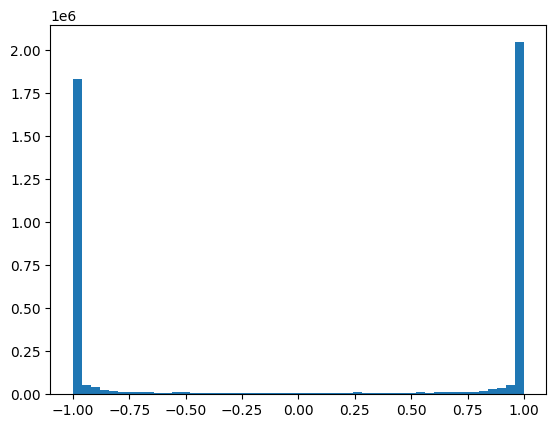

In [17]:
plt.hist(h.view(-1).tolist(), 50)
plt.show()

"h" is the tanh layer of the network. and we can see it's initialized heavily towards 1 and -1. This is bad because gradient cannot go through. Reason:

the backward function for tanh is defined as (referencing micrograd):
```python
def tanh(self):
    ...
    def _backward():
        self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    ...
```

now "t" is initialized heavily towards 1 and -1, making $t^2$ term close to 1. so $(1 - t^2)$ is close to 0, gradient cannot go through.

same issue can happen to sigmoid and ReLU as well.

Fix: initialize W1 to be small.

In [42]:
# better initialization
input_size = emb_dim * block_size

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((num_chars, emb_dim), generator=g)
W1 = torch.randn((input_size, hidden_size), generator=g) * 0.1
b1 = torch.zeros(hidden_size)
W2 = torch.randn((hidden_size, num_chars), generator=g) * 0.01
b2 = torch.zeros(num_chars)

params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

# forward pass and print loss
emb = C[Xdev]
embcat = emb.view(-1, input_size)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
dev_loss = F.cross_entropy(logits, Ydev)
print(f"{dev_loss=}")

dev_loss=tensor(3.3053, grad_fn=<NllLossBackward0>)


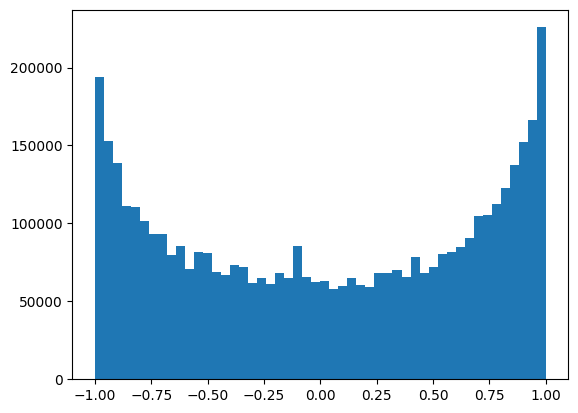

In [36]:
plt.hist(h.view(-1).tolist(), 50)
plt.show()

100%|██████████| 100000/100000 [16:58<00:00, 98.18it/s] 


dev_loss.item()=2.0804924964904785


2.0804924964904785

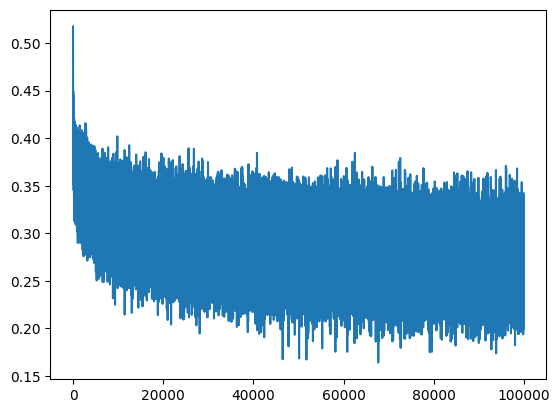

In [43]:
train(num_iterations=num_iterations, input_size=emb_dim * block_size, lr=lr, batch_size=batch_size, parameters=params)

100%|██████████| 100000/100000 [11:26<00:00, 145.63it/s]


dev_loss.item()=2.0544087886810303


2.0544087886810303

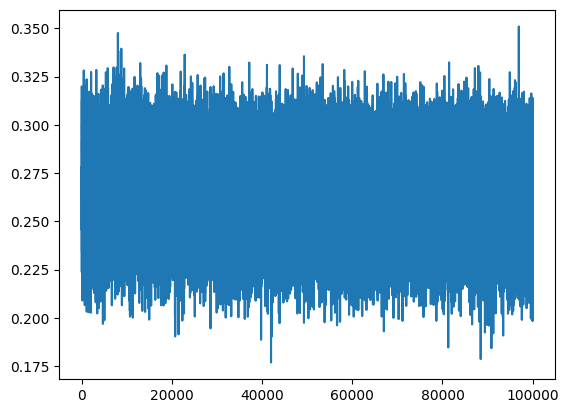

In [44]:
train(num_iterations=num_iterations, input_size=emb_dim * block_size, lr=0.01, batch_size=256, parameters=params)

100%|██████████| 100000/100000 [03:49<00:00, 436.15it/s]


dev_loss.item()=2.062053918838501


2.062053918838501

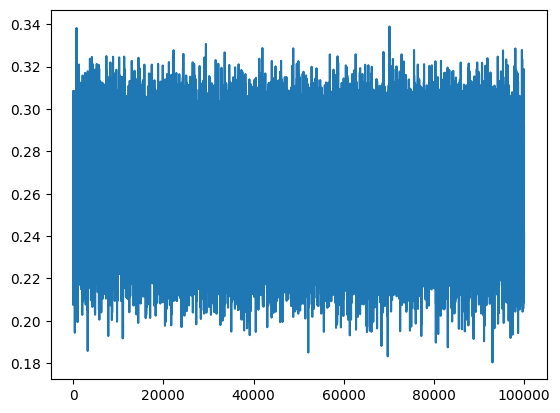

In [45]:
train(num_iterations=num_iterations, input_size=emb_dim * block_size, lr=0.01, batch_size=256, parameters=params)

starts to overfit, but uniform initialization achieves lower dev (~2.05) loss than random initialization (~2.13).

## E03:
Read the Bengio et al 2003 paper, implement and try any idea from the paper. Did it work?
https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf

In [46]:
# direct connection from C to output layer
def create_network(emb_dim, block_size, hidden_size):
    input_size = emb_dim * block_size
    g = torch.Generator().manual_seed(2147483647)
    g = torch.Generator().manual_seed(2147483647)
    C = torch.randn((num_chars, emb_dim), generator=g)
    W1 = torch.randn((input_size, hidden_size), generator=g) * 0.1
    b1 = torch.zeros(hidden_size)
    W2 = torch.randn((hidden_size, num_chars), generator=g) * 0.01
    b2 = torch.zeros(num_chars)
    Wd = torch.zeros((input_size, num_chars))  # ← new

    params = [C, W1, b1, W2, b2, Wd]
    for p in params:
        p.requires_grad = True

    return [C, W1, b1, W2, b2, Wd]

In [47]:
def train(num_iterations, input_size, lr, batch_size, parameters):

    C, W1, b1, W2, b2, Wd = parameters

    for i in tqdm(range(num_iterations)):
        # minibatch construct
        ix = torch.randint(0, Xtr.shape[0], (batch_size,))

        # forward pass
        emb = C[Xtr[ix]]
        emb_flat = emb.view(-1, input_size)
        h = torch.tanh(emb_flat @ W1 + b1)
        logits = h @ W2 + b2 + emb_flat @ Wd
        loss = F.cross_entropy(logits, Ytr[ix])

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        for p in parameters:
            p.data += -lr * p.grad

    # dev loss
    emb = C[Xdev]
    emb_flat = emb.view(-1, input_size)
    h = torch.tanh(emb_flat @ W1 + b1)
    logits = h @ W2 + b2 + emb_flat @ Wd
    dev_loss = F.cross_entropy(logits, Ydev)

    print(f"{dev_loss.item()=}")

    return dev_loss.item()

In [48]:
num_chars = 27
num_iterations = 100000
batch_size = 128
block_size = 4

In [239]:
results = []
for emb_dim in [10, 30]:
    for hidden_size in [200, 300]:
        for lr in [0.2, 0.1, 0.05]:
            params = create_network(
                emb_dim=emb_dim,
                block_size=block_size,
                hidden_size=hidden_size,
            )
            dev_loss = train(
                num_iterations=num_iterations,
                input_size=emb_dim * block_size,
                lr=lr,
                batch_size=batch_size,
                parameters=params,
            )
            results.append(
                {
                    "emb_dim": emb_dim,
                    "hidden_size": hidden_size,
                    "lr": lr,
                    "dev_loss": dev_loss,
                }
            )

best = min(results, key=lambda r: r["dev_loss"])
print(best)

100%|██████████| 100000/100000 [02:07<00:00, 784.11it/s]


dev_loss.item()=2.0959055423736572


100%|██████████| 100000/100000 [02:12<00:00, 756.75it/s]


dev_loss.item()=2.079265594482422


100%|██████████| 100000/100000 [02:15<00:00, 736.91it/s]


...

dev_loss.item()=2.092033624649048


100%|██████████| 100000/100000 [02:07<00:00, 787.11it/s]


dev_loss.item()=2.0690417289733887


100%|██████████| 100000/100000 [01:58<00:00, 844.33it/s]

dev_loss.item()=2.0531227588653564
{'emb_dim': 30, 'hidden_size': 300, 'lr': 0.05, 'dev_loss': 2.0531227588653564}


In [ ]:
# retrain
best = min(results, key=lambda r: r["dev_loss"])
params = create_network(
    emb_dim=best["emb_dim"],
    block_size=block_size,
    hidden_size=best["hidden_size"],
)

In [53]:
train(num_iterations=num_iterations, input_size=best["emb_dim"] * block_size, lr=best["lr"], batch_size=batch_size, parameters=params)

100%|██████████| 100000/100000 [04:09<00:00, 401.09it/s]


dev_loss.item()=2.064577102661133


2.064577102661133

In [245]:
train(num_iterations=50000, input_size=best["emb_dim"] * block_size, lr=0.01, batch_size=256, parameters=params)

100%|██████████| 50000/50000 [05:18<00:00, 157.12it/s] 

dev_loss.item()=2.0261898040771484


2.0261898040771484

better dev loss

In [54]:
# loss on test set
emb = C[Xte]
h = torch.tanh(emb.view(-1, input_size) @ W1 + b1)
logits = h @ W2 + b2
test_loss = F.cross_entropy(logits, Yte)
print(f"{test_loss.item()=}")

test_loss.item()=2.0583646297454834
